In [1]:
from TM_SI import fixed_tuning_TM_SI_randj
from practical_transmission import noise_score_references
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

c:\Ananconda\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.sparse import csr_array, issparse

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Ananconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Ananconda\Lib\site-packages\traitlets\config\application.py", line 10

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
p, nt, ns, K = 100, 30, 50, 2
sigma = 1.0
quantile = 0.35
n_rep = 1000

In [3]:
rng = np.random.default_rng()

X0 = rng.standard_normal((nt, p))
X_list = [rng.standard_normal((ns, p)) for _ in range(K)]

Sigma_0 = sigma ** 2 * np.eye(nt)
Sigma_K = [sigma ** 2 * np.eye(ns) for _ in range(K)]

lambda_0, lambda_T = noise_score_references(
    X0, X_list, sigma=sigma, quantile=quantile,
    n_draws=5000, batch_size=250, seed=None,
)
print(f'lambda_0 = {lambda_0:.5f}   lambda_T = {lambda_T:.5f}')

lambda_0 = 0.22697   lambda_T = 0.45359


In [4]:
def run(n_rep):
    p_values, branches, n_empty = [], [], 0

    for i in range(1, n_rep + 1):
        y0 = sigma * rng.standard_normal(nt)
        y_list = [sigma * rng.standard_normal(ns) for _ in range(K)]

        result = fixed_tuning_TM_SI_randj(
            X0, y0, X_list, y_list, lambda_0, lambda_T,
            Sigma_0, Sigma_K, rng=rng,
        )

        if result['results']:
            p_values.append(result['results'][0]['p_value'])
            branches.append(result['branch'])
        else:
            n_empty += 1

        if i % 50 == 0:
            print(f"{i}/{n_rep}, "
                  f"p-values: {len(p_values)}, "
                  f"empty models: {n_empty}",)

    return np.array(p_values), branches, n_empty

In [10]:
list_p_value, _, _ = run(n_rep)

50/1000, p-values: 38, empty models: 12
100/1000, p-values: 71, empty models: 29
150/1000, p-values: 107, empty models: 43
200/1000, p-values: 143, empty models: 57
250/1000, p-values: 177, empty models: 73
300/1000, p-values: 207, empty models: 93
350/1000, p-values: 240, empty models: 110
400/1000, p-values: 274, empty models: 126
450/1000, p-values: 306, empty models: 144
500/1000, p-values: 340, empty models: 160
550/1000, p-values: 370, empty models: 180
600/1000, p-values: 401, empty models: 199
650/1000, p-values: 428, empty models: 222
700/1000, p-values: 460, empty models: 240
750/1000, p-values: 490, empty models: 260
800/1000, p-values: 524, empty models: 276
850/1000, p-values: 559, empty models: 291
900/1000, p-values: 595, empty models: 305
950/1000, p-values: 621, empty models: 329
1000/1000, p-values: 650, empty models: 350


In [11]:
alpha = 0.05
FPR = np.mean(list_p_value <= alpha)
print(f"FPR = {FPR}")

FPR = 0.04461538461538461


In [12]:
statistic, p_value = stats.kstest(list_p_value, 'uniform')
print(f'KS-Test statistic = {statistic}')
print(f'KS-Test p-value = {p_value}')

KS-Test statistic = 0.028977640684882067
KS-Test p-value = 0.6352328383292913


(array([29., 33., 30., 36., 33., 36., 28., 25., 37., 37., 27., 29., 27.,
        35., 29., 33., 38., 36., 36., 36.]),
 array([0.00150823, 0.05122931, 0.1009504 , 0.15067148, 0.20039257,
        0.25011365, 0.29983474, 0.34955582, 0.3992769 , 0.44899799,
        0.49871907, 0.54844016, 0.59816124, 0.64788233, 0.69760341,
        0.7473245 , 0.79704558, 0.84676666, 0.89648775, 0.94620883,
        0.99592992]),
 <BarContainer object of 20 artists>)

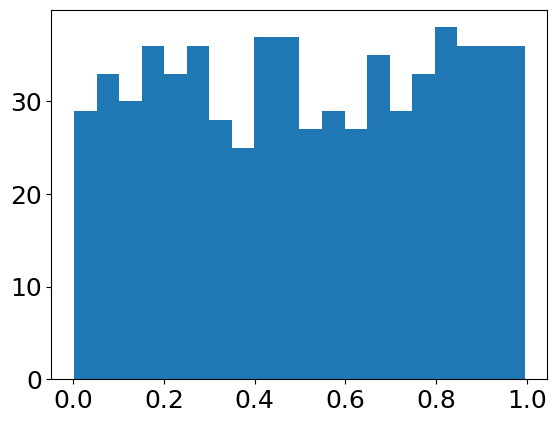

In [13]:
plt.hist(list_p_value, bins=20)

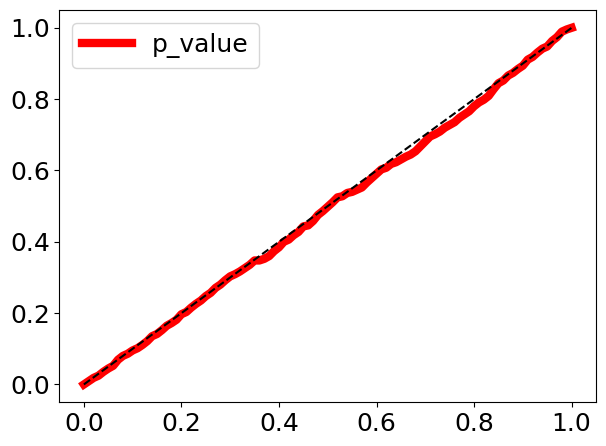

In [14]:
plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
ecdf = np.searchsorted(np.sort(list_p_value), grid, side='right') / len(list_p_value)
plt.plot(grid, ecdf, 'r-', linewidth=6, label='p_value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()